In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('/content/ecommerce retail.xlsx', sheet_name='ecommerce retail')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [ ]:
#EDA
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.drop(columns=['Description'], inplace=True)


In [ ]:
df_rfm = df.dropna(subset = 'CustomerID').copy()
df_unknown = df[df['CustomerID'].isna()].copy()  # CustomerID is null

In [ ]:
df_rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Quantity     406829 non-null  int64         
 3   InvoiceDate  406829 non-null  datetime64[ns]
 4   UnitPrice    406829 non-null  float64       
 5   CustomerID   406829 non-null  float64       
 6   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 24.8+ MB


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Quantity     541909 non-null  int64         
 3   InvoiceDate  541909 non-null  datetime64[ns]
 4   UnitPrice    541909 non-null  float64       
 5   CustomerID   406829 non-null  float64       
 6   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 28.9+ MB


In [ ]:
df_rfm['CustomerID']= df_rfm['CustomerID'].astype(int)
df_rfm

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,22613,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,4,2011-12-09 12:50:00,4.15,12680,France


In [ ]:
#Assumption
df_rfm2 = df_rfm.groupby(df_rfm['Country'], as_index = False).agg({'InvoiceNo': 'count'}).sort_values('InvoiceNo', ascending=False)
df_rfm2['percentage'] = round(100* df_rfm2['InvoiceNo']/len(df_rfm), 2)
df_rfm2

,Country,InvoiceNo,percentage
35,United Kingdom,361878,88.95
14,Germany,9495,2.33
13,France,8491,2.09
10,EIRE,7485,1.84
30,Spain,2533,0.62
23,Netherlands,2371,0.58
3,Belgium,2069,0.51
32,Switzerland,1877,0.46
26,Portugal,1480,0.36
0,Australia,1259,0.31


In [ ]:
df_uk = df_rfm[df_rfm['Country'] == 'United Kingdom'].copy()
df_others = df_rfm[df_rfm['Country'] != 'United Kingdom'].copy()
df_uk

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...
541889,581585,22466,12,2011-12-09 12:31:00,1.95,15804,United Kingdom
541890,581586,22061,8,2011-12-09 12:49:00,2.95,13113,United Kingdom
541891,581586,23275,24,2011-12-09 12:49:00,1.25,13113,United Kingdom
541892,581586,21217,24,2011-12-09 12:49:00,8.95,13113,United Kingdom


In [ ]:
df_others_sales = df_others[df_others['Quantity'] > 0].copy()
df_others_sales.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,43579.000000,43579,43579.000000,43579.000000
mean,20.932651,2011-07-08 03:46:14.070997504,4.355204,13195.508341
min,1.000000,2010-12-01 08:45:00,0.000000,12347.000000
25%,6.000000,2011-04-05 11:03:00,1.250000,12484.000000
50%,12.000000,2011-07-28 14:27:00,1.950000,12662.000000
75%,18.000000,2011-10-11 14:59:00,3.750000,14156.000000
max,2400.000000,2011-12-09 12:50:00,4161.060000,17844.000000
std,47.993824,NaN,43.156494,1085.662531


In [ ]:
df_uk.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,361878.000000,361878,361878.000000,361878.000000
mean,11.077029,2011-07-10 23:48:12.301493760,3.256007,15547.871368
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-06 17:25:00,1.250000,14194.000000
50%,4.000000,2011-07-31 13:07:00,1.950000,15514.000000
75%,12.000000,2011-10-23 11:39:00,3.750000,16931.000000
max,80995.000000,2011-12-09 12:49:00,38970.000000,18287.000000
std,263.129266,NaN,70.654731,1594.402590


In [ ]:
df_uk_sales = df_uk[df_uk['Quantity'] > 0].copy()
df_uk_sales.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,354345.000000,354345,354345.000000,354345.000000
mean,12.048913,2011-07-11 08:05:04.229606656,2.963793,15552.436219
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-07 11:40:00,1.250000,14194.000000
50%,4.000000,2011-07-31 15:31:00,1.950000,15522.000000
75%,12.000000,2011-10-23 13:49:00,3.750000,16931.000000
max,80995.000000,2011-12-09 12:49:00,8142.750000,18287.000000
std,190.428127,NaN,17.862067,1594.546025


In [ ]:
recency = (
    df_uk_sales.groupby('CustomerID')['InvoiceDate']
    .max()
    .reset_index()
)
recency['Recency'] = (pd.to_datetime('2011-12-31') - pd.to_datetime(recency['InvoiceDate'])).dt.days
recency = recency[['CustomerID', 'Recency']]
recency


,CustomerID,Recency
0,12346,346
1,12747,23
2,12748,21
3,12749,24
4,12820,24
...,...,...
3916,18280,298
3917,18281,201
3918,18282,28
3919,18283,24


In [ ]:
df_uk_sales['Monetary'] = df_uk_sales['Quantity'] * df_uk_sales['UnitPrice']
monetary = (
    df_uk_sales.groupby('CustomerID')['Monetary']
    .sum()
    .reset_index()
)
monetary

,CustomerID,Monetary
0,12346,77183.60
1,12747,4196.01
2,12748,33719.73
3,12749,4090.88
4,12820,942.34
...,...,...
3916,18280,180.60
3917,18281,80.82
3918,18282,178.05
3919,18283,2094.88


In [ ]:
frequency = (
    df_uk_sales.groupby('CustomerID')['InvoiceNo']
    .nunique()
    .reset_index()
    .rename(columns={'InvoiceNo': 'Frequency'})
)
frequency

,CustomerID,Frequency
0,12346,1
1,12747,11
2,12748,210
3,12749,5
4,12820,4
...,...,...
3916,18280,1
3917,18281,1
3918,18282,2
3919,18283,16


In [ ]:
#Calculate RFM
rfm_uk = recency.merge(frequency, on='CustomerID').merge(monetary, on='CustomerID')
rfm_uk.describe()


,CustomerID,Recency,Frequency,Monetary
count,3921.000000,3921.000000,3921.000000,3921.000000
mean,15561.471563,112.722265,4.246111,1863.910113
std,1576.823683,99.528532,7.205750,7481.922217
min,12346.000000,21.000000,1.000000,0.000000
25%,14208.000000,38.000000,1.000000,300.040000
50%,15569.000000,71.000000,2.000000,651.820000
75%,16913.000000,163.000000,5.000000,1575.890000
max,18287.000000,394.000000,210.000000,259657.300000


In [ ]:
# (RFM)Divide results by levels 1,2,3,4,5
# R_score
rfm_uk['R_score'] = pd.qcut(rfm_uk['Recency'], 5, labels=[5,4,3,2,1], duplicates='drop')

# F_score
rfm_uk['F_score'] = pd.cut(
    rfm_uk['Frequency'],
    bins=[0, 1, 3, 5, 10, rfm_uk['Frequency'].max()],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
)

# M_score
rfm_uk['M_score'] = pd.cut(
    rfm_uk['Monetary'],
    bins=[0, 300, 650, 1600, 5000, rfm_uk['Monetary'].max()],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
)

# RFM
rfm_uk['RFM'] = rfm_uk['R_score'].astype(str) + rfm_uk['F_score'].astype(str) + rfm_uk['M_score'].astype(str)

rfm_uk

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM
0,12346,346,1,77183.60,1,1,5,115
1,12747,23,11,4196.01,5,5,4,554
2,12748,21,210,33719.73,5,5,5,555
3,12749,24,5,4090.88,5,3,4,534
4,12820,24,4,942.34,5,3,3,533
...,...,...,...,...,...,...,...,...
3916,18280,298,1,180.60,1,1,1,111
3917,18281,201,1,80.82,1,1,1,111
3918,18282,28,2,178.05,5,2,1,521
3919,18283,24,16,2094.88,5,5,4,554


In [ ]:
# segmentation
segment_dict = {
    'Champions': ['555','554','544','545','454','455','445'],
    'Loyal': ['543','444','435','355','354','345','344','335'],
    'Potential Loyalist': ['553','551','552','541','542','533','532','531','452','451','442','441','431','453','433','432','423','353','352','351','342','341','333','323'],
    'New Customers': ['512','511','422','421','412','411','311'],
    'Promising': ['525','524','523','522','521','515','514','513','425','424','413','414','415','315','314','313'],
    'Need Attention': ['535','534','443','434','343','334','325','324'],
    'About To Sleep': ['331','321','312','221','213','231','241','251'],
    'At Risk': ['255','254','245','244','253','252','243','242','235','234','225','224','153','152','145','143','142','135','134','133','125','124'],
    'Cannot Lose Them': ['155','154','144','214','215','115','114','113'],
    'Hibernating': ['332','322','233','232','223','222','132','123','122','212','211'],
    'Lost customers': ['111','112','121','131','141','151']
}

def seg(data):
  for segment , score in segment_dict.items():
    if data in score:
      return segment

rfm_uk['Segment'] = rfm_uk['RFM'].apply(seg)

rfm_uk # Customers from the UK

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM,Segment
0,12346,346,1,77183.60,1,1,5,115,Cannot Lose Them
1,12747,23,11,4196.01,5,5,4,554,Champions
2,12748,21,210,33719.73,5,5,5,555,Champions
3,12749,24,5,4090.88,5,3,4,534,Need Attention
4,12820,24,4,942.34,5,3,3,533,Potential Loyalist
...,...,...,...,...,...,...,...,...,...
3916,18280,298,1,180.60,1,1,1,111,Lost customers
3917,18281,201,1,80.82,1,1,1,111,Lost customers
3918,18282,28,2,178.05,5,2,1,521,Promising
3919,18283,24,16,2094.88,5,5,4,554,Champions


In [ ]:
 country = df_others_sales[['CustomerID','Country']].drop_duplicates()
 country

,CustomerID,Country
26,12583,France
197,12431,Australia
385,12791,Netherlands
1109,12662,Germany
1236,12433,Norway
...,...,...
527384,12367,Denmark
529740,12478,Greece
531420,12442,Spain
532691,12650,France


In [ ]:
country_counts = df_others_sales.groupby('CustomerID')['Country'].nunique().reset_index()
multi_country_customers = country_counts[country_counts['Country'] > 1]
multi_country_customers

,CustomerID,Country
19,12370,2
37,12394,2
55,12417,2
59,12422,2
66,12429,2
68,12431,2
89,12455,2
91,12457,2


In [ ]:
details = df_others_sales[df_others_sales['CustomerID'].isin(multi_country_customers['CustomerID'])]
details.sort_values(['CustomerID', 'InvoiceDate'])

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
29732,538826,85123A,64,2010-12-14 12:58:00,2.55,12370,Cyprus
29733,538826,21031,10,2010-12-14 12:58:00,1.25,12370,Cyprus
29734,538826,21026,10,2010-12-14 12:58:00,1.25,12370,Cyprus
29735,538826,21025,10,2010-12-14 12:58:00,1.25,12370,Cyprus
29736,538826,21032,10,2010-12-14 12:58:00,1.25,12370,Cyprus
...,...,...,...,...,...,...,...
341362,566756,21709,4,2011-09-14 15:54:00,4.95,12457,Switzerland
341363,566756,23245,8,2011-09-14 15:54:00,4.95,12457,Switzerland
342913,566916,POST,4,2011-09-15 14:25:00,40.00,12457,Switzerland
346549,567188,15056N,33,2011-09-19 09:04:00,5.95,12457,Cyprus


In [ ]:
# Other countries
recency_2 = (
    df_others_sales.groupby('CustomerID')['InvoiceDate']
    .max()
    .reset_index()
)
recency_2['Recency'] = (pd.to_datetime('2011-12-31') - pd.to_datetime(recency_2['InvoiceDate'])).dt.days
recency_2 = recency_2[['CustomerID', 'Recency']]

frequency_2 = (
    df_others_sales.groupby('CustomerID')['InvoiceNo']
    .nunique()
    .reset_index()
    .rename(columns={'InvoiceNo': 'Frequency'})
)

df_others_sales['Monetary'] = df_others_sales['Quantity'] * df_others_sales['UnitPrice']
monetary_2 = (
    df_others_sales.groupby('CustomerID')['Monetary']
    .sum()
    .reset_index()
)

# merge
rfm_others = recency_2.merge(frequency_2, on='CustomerID').merge(monetary_2, on='CustomerID')

# (RFM)Divide results by levels 1,2,3,4,5
# R_score
rbins = pd.qcut(rfm_others['Recency'], 5, retbins=True)[1]
rfm_others['R_score'] = pd.cut(rfm_others['Recency'], bins=rbins, labels=[5,4,3,2,1], include_lowest=True)

# F_score
rfm_others['F_score'] = pd.cut(
    rfm_others['Frequency'],
    bins=[0, 1, 3, 5, 10, rfm_others['Frequency'].max()],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
)

# M_score
rfm_others['M_score'] = pd.cut(
    rfm_others['Monetary'],
    bins=[0, 300, 650, 1600, 5000, rfm_others['Monetary'].max()],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
)

# RFM
rfm_others['RFM'] = rfm_others['R_score'].astype(str) + rfm_others['F_score'].astype(str) + rfm_others['M_score'].astype(str)

def seg(data):
  for segment , score in segment_dict.items():
    if data in score:
      return segment
rfm_others['Segment'] = rfm_others['RFM'].apply(seg)

rfm_others # Analyze by 'customer' not include 'country' - one row per customer (all countries combined)

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM,Segment
0,12347,23,7,4310.00,5,4,4,544,Champions
1,12348,96,4,1797.24,2,3,4,234,At Risk
2,12349,39,1,1757.55,4,1,4,414,Promising
3,12350,331,1,334.40,1,1,2,112,Lost customers
4,12352,57,8,2506.04,3,4,4,344,Loyal
...,...,...,...,...,...,...,...,...,...
413,17444,168,3,2940.04,2,2,4,224,At Risk
414,17508,301,1,387.31,1,1,2,112,Lost customers
415,17828,43,4,1820.09,4,3,4,434,Need Attention
416,17829,319,1,889.24,1,1,3,113,Cannot Lose Them


In [ ]:
# recency
recency_3 = (
    df_others_sales.groupby(['CustomerID', 'Country'])['InvoiceDate']
    .max()
    .reset_index()
)
recency_3['Recency'] = (pd.to_datetime('2011-12-31') - pd.to_datetime(recency_3['InvoiceDate'])).dt.days
recency_3 = recency_3[['CustomerID', 'Country', 'Recency']]

# frequency
frequency_3 = (
    df_others_sales.groupby(['CustomerID', 'Country'])['InvoiceNo']
    .nunique()
    .reset_index()
    .rename(columns={'InvoiceNo': 'Frequency'})
)

# monetary
monetary_3 = (
    df_others_sales.groupby(['CustomerID', 'Country'])['Monetary']
    .sum()
    .reset_index()
)

# merge
rfm_others_country = (
    recency_3
    .merge(frequency_3, on=['CustomerID', 'Country'])
    .merge(monetary_3, on=['CustomerID', 'Country'])
)

# RFM
rfm_others_country['R_score'] = pd.cut(rfm_others_country['Recency'], bins=rbins, labels=[5,4,3,2,1], include_lowest=True)

rfm_others_country['F_score'] = pd.cut(
    rfm_others_country['Frequency'],
    bins=[0, 1, 3, 5, 10, rfm_others_country['Frequency'].max()],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
)

rfm_others_country['M_score'] = pd.cut(
    rfm_others_country['Monetary'],
    bins=[0, 300, 650, 1600, 5000, rfm_others_country['Monetary'].max()],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
)

rfm_others_country['RFM'] = (rfm_others_country['R_score'].astype(str)+ rfm_others_country['F_score'].astype(str)+ rfm_others_country['M_score'].astype(str))

def seg(data):
  for segment , score in segment_dict.items():
    if data in score:
      return segment
rfm_others_country['Segment'] = rfm_others_country['RFM'].apply(seg)

rfm_others_country # Analyze by country (one row per customer per country)

,CustomerID,Country,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM,Segment
0,12347,Iceland,23,7,4310.00,5,4,4,544,Champions
1,12348,Finland,96,4,1797.24,2,3,4,234,At Risk
2,12349,Italy,39,1,1757.55,4,1,4,414,Promising
3,12350,Norway,331,1,334.40,1,1,2,112,Lost customers
4,12352,Norway,57,8,2506.04,3,4,4,344,Loyal
...,...,...,...,...,...,...,...,...,...,...
421,17444,Canada,168,3,2940.04,2,2,4,224,At Risk
422,17508,Greece,301,1,387.31,1,1,2,112,Lost customers
423,17828,Malta,43,4,1820.09,4,3,4,434,Need Attention
424,17829,United Arab Emirates,319,1,889.24,1,1,3,113,Cannot Lose Them


In [ ]:
#rfm_uk
#rfm_others - Analyze by customer - one row per customer (all countries combined)
#rfm_others_country - Analyze by country (one row per customer per country)

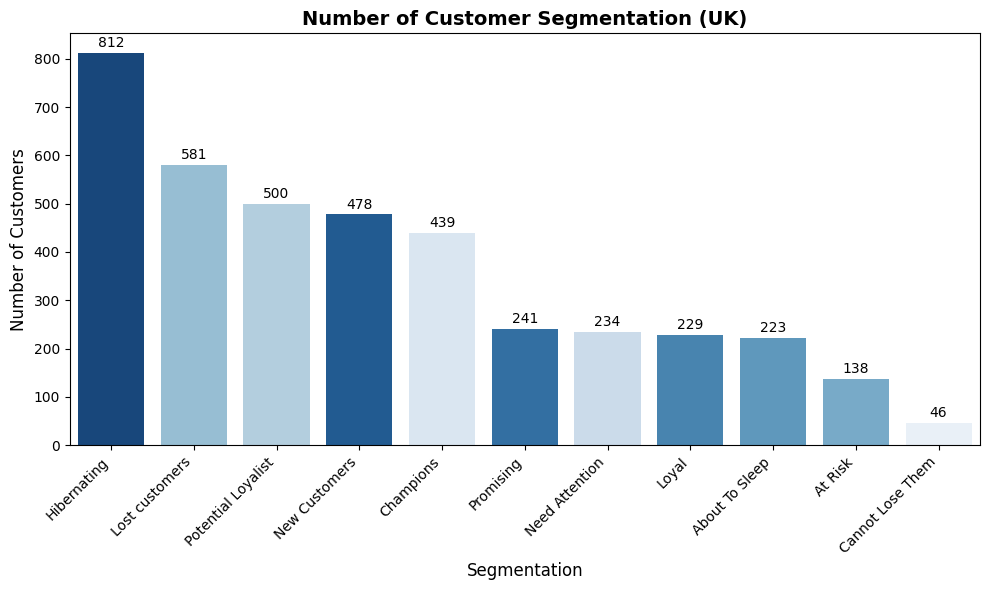

In [ ]:
seg_order = rfm_uk['Segment'].value_counts().index

plt.figure(figsize=(10,6))
ax = sns.countplot(
    x='Segment',
    data=rfm_uk,
    order=seg_order,
    hue='Segment',
    palette= 'Blues',
    legend=False
)

plt.title('Number of Customer Segmentation (UK)', fontsize=14, fontweight='bold')
plt.xlabel('Segmentation', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')

# data label
for i in ax.containers:
    ax.bar_label(i, padding=2,fontsize=10)

plt.tight_layout()
plt.show()

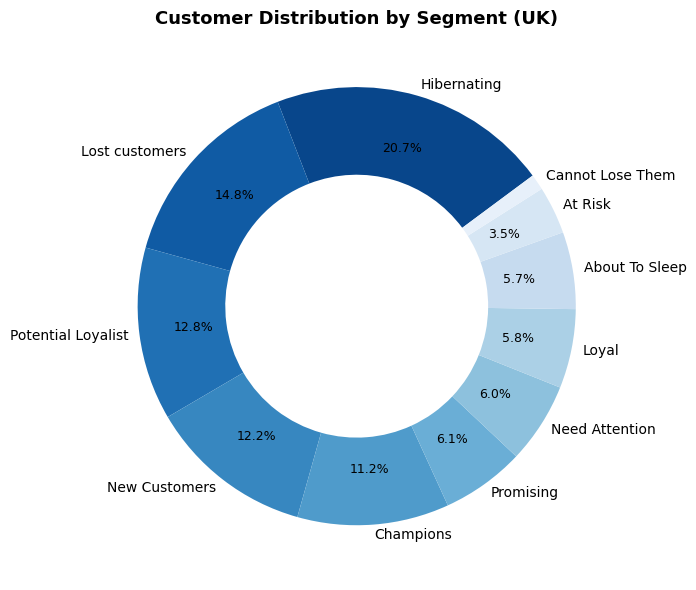

In [ ]:
total_customers =  rfm_uk['CustomerID'].nunique() + rfm_others['CustomerID'].nunique()
count_data = rfm_uk['Segment'].value_counts().reset_index()
count_data.columns = ['Segment', 'Customer Count']
count_data['Customer %'] = 100 * count_data['Customer Count'] / total_customers

def autopct_filter(pct):
    return f'{pct:.1f}%' if pct >= 2 else ''

# Tính góc bắt đầu cho mỗi lát (để biết lát nào là "Cannot Lose Them")
angles = 360 * count_data['Customer %'].cumsum() / 100 - (360 * count_data['Customer %'] / 200)
target_segment = "Cannot Lose Them"

if target_segment in count_data['Segment'].values:
    target_angle = angles[count_data['Segment'] == target_segment].values[0]
else:
    target_angle = 0

# Muốn lát đó nằm giữa bên phải (0°), thì startangle = -target_angle
start_angle = -target_angle

# Vẽ donut chart
plt.figure(figsize=(8,6))
wedges, texts, autotexts = plt.pie(
    count_data['Customer Count'],
    labels=count_data['Segment'],
    autopct=autopct_filter,
    startangle=start_angle,
    colors=sns.color_palette('Blues', len(count_data))[::-1],
    pctdistance=0.75,
    labeldistance=1.05,
    wedgeprops={'width':0.4}
)
plt.setp(autotexts, size=9)
plt.title('Customer Distribution by Segment (UK)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


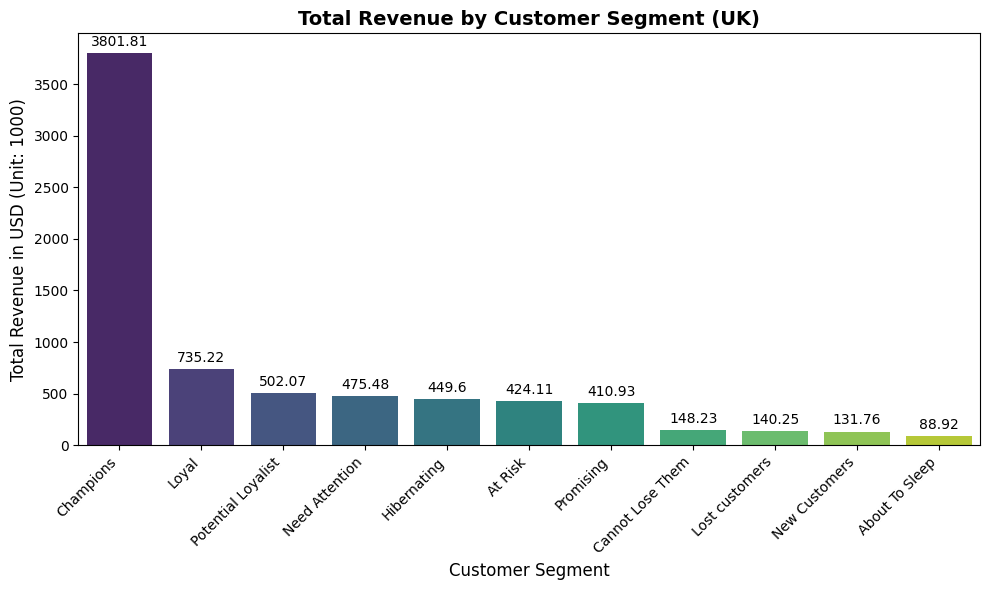

In [ ]:
# Tính tổng doanh thu theo nhóm
rev_segment = rfm_uk.groupby('Segment')['Monetary'].sum().reset_index().sort_values('Monetary', ascending=False)
rev_segment['Monetary_K'] = round(rev_segment['Monetary']/ 1000,2)

# Vẽ biểu đồ
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=rev_segment,
    x='Segment',
    y='Monetary_K',
    hue='Segment',
    legend = False,
    palette='viridis')

plt.title('Total Revenue by Customer Segment (UK)', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Total Revenue in USD (Unit: 1000)', fontsize=12)

# Thêm nhãn giá trị trên cột
for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

plt.xticks(rotation=45, ha = 'right')
plt.tight_layout()
plt.show()


In [ ]:
total_revenue = (df_rfm['Quantity'] * df_rfm['UnitPrice']).sum()
rev_segment['Revenue Share (%)'] = 100 * rev_segment['Monetary'] / total_revenue
range_stats = (
    rfm_uk.groupby('Segment')['Monetary']
    .agg(['min', 'max'])
    .reset_index()
)

# Gộp vào rev_segment
rev_segment = rev_segment.merge(range_stats, on='Segment', how='left')
rev_segment['Spending Range'] = (
    rev_segment['min'].astype(int).astype(str)
    + " - " +
    rev_segment['max'].astype(int).astype(str)
)
rev_segment

,Segment,Monetary,Monetary_K,Revenue Share (%),min,max,Spending Range
0,Champions,3801811.650,3801.81,45.804596,1604.75,259657.30,1604 - 259657
1,Loyal,735220.710,735.22,8.858011,808.62,81024.84,808 - 81024
2,Potential Loyalist,502065.451,502.07,6.048933,201.12,1592.12,201 - 1592
3,Need Attention,475479.670,475.48,5.728625,694.40,4932.20,694 - 4932
4,Hibernating,449601.132,449.60,5.416838,13.30,1590.81,13 - 1590
5,At Risk,424112.601,424.11,5.109750,319.50,44534.30,319 - 44534
6,Promising,410931.480,410.93,4.950942,52.20,168472.50,52 - 168472
7,Cannot Lose Them,148230.470,148.23,1.785895,660.00,77183.60,660 - 77183
8,Lost customers,140253.390,140.25,1.689786,3.75,635.66,3 - 635
9,New Customers,131761.270,131.76,1.587473,0.00,642.80,0 - 642


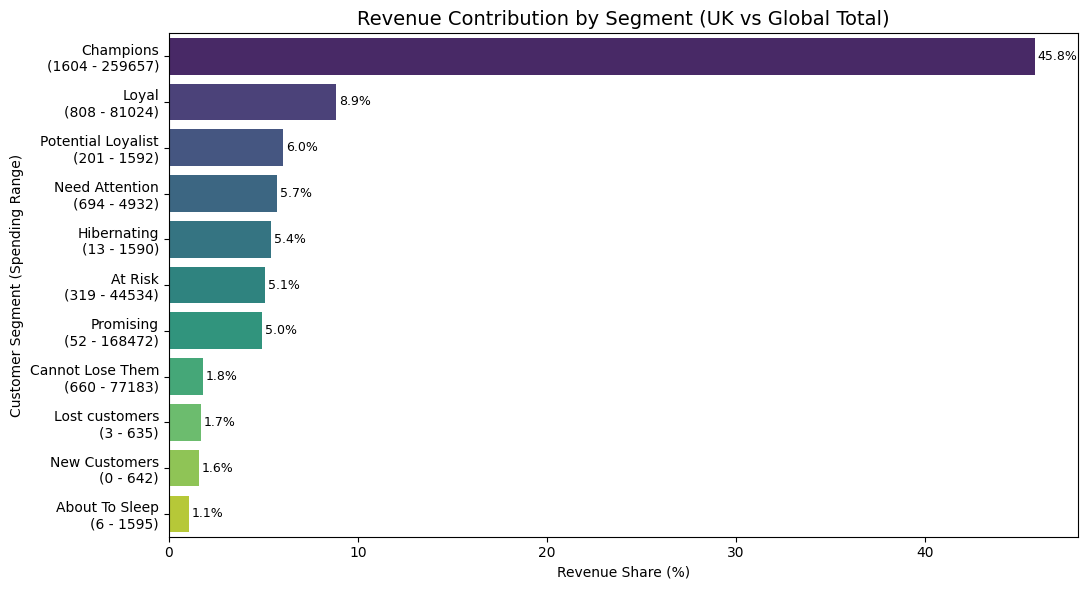

In [ ]:
rev_segment['Segment_Label'] = rev_segment['Segment'] + '\n(' + rev_segment['Spending Range'] + ')'

# Sắp xếp theo doanh thu giảm dần
rev_segment = rev_segment.sort_values('Revenue Share (%)', ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=rev_segment,
    x='Revenue Share (%)',
    y='Segment_Label',
    hue='Segment',
    legend=False,
    palette='viridis'
)

plt.title('Revenue Contribution by Segment (UK vs Global Total)', fontsize=14)
plt.ylabel('Customer Segment (Spending Range)')
plt.xlabel('Revenue Share (%)')

# Thêm data labels hiển thị giá trị doanh thu
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding = 2, fontsize=9)

plt.tight_layout()
plt.show()

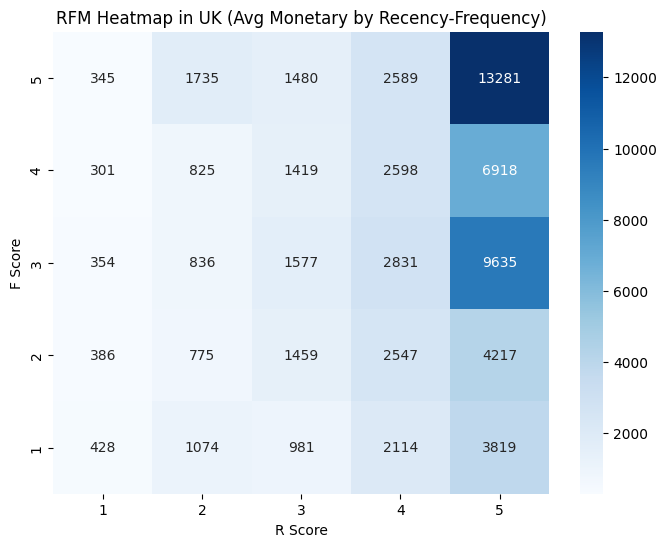

In [ ]:
rfm_heatmap = rfm_uk.groupby(['R_score', 'F_score'], observed=False)['Monetary'].mean().unstack()

plt.figure(figsize=(8,6))
sns.heatmap(rfm_heatmap, cmap='Blues', annot=True, fmt='.0f')
plt.title('RFM Heatmap in UK (Avg Monetary by Recency-Frequency)')
plt.xlabel('R Score')
plt.ylabel('F Score')
plt.show()

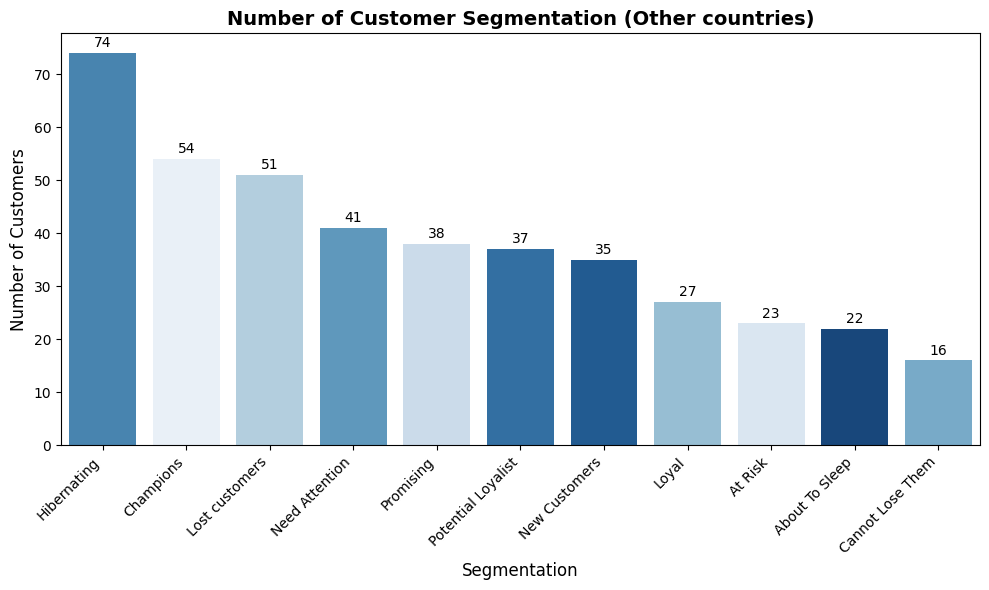

In [ ]:
seg_order_2 = rfm_others['Segment'].value_counts().index

plt.figure(figsize=(10,6))
ax = sns.countplot(
    x='Segment',
    data=rfm_others,
    order=seg_order_2,
    hue='Segment',
    palette= 'Blues',
    legend=False
)

plt.title('Number of Customer Segmentation (Other countries)', fontsize=14, fontweight='bold')
plt.xlabel('Segmentation', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')

# data label
for i in ax.containers:
    ax.bar_label(i, padding=2,fontsize=10)

plt.tight_layout()
plt.show()

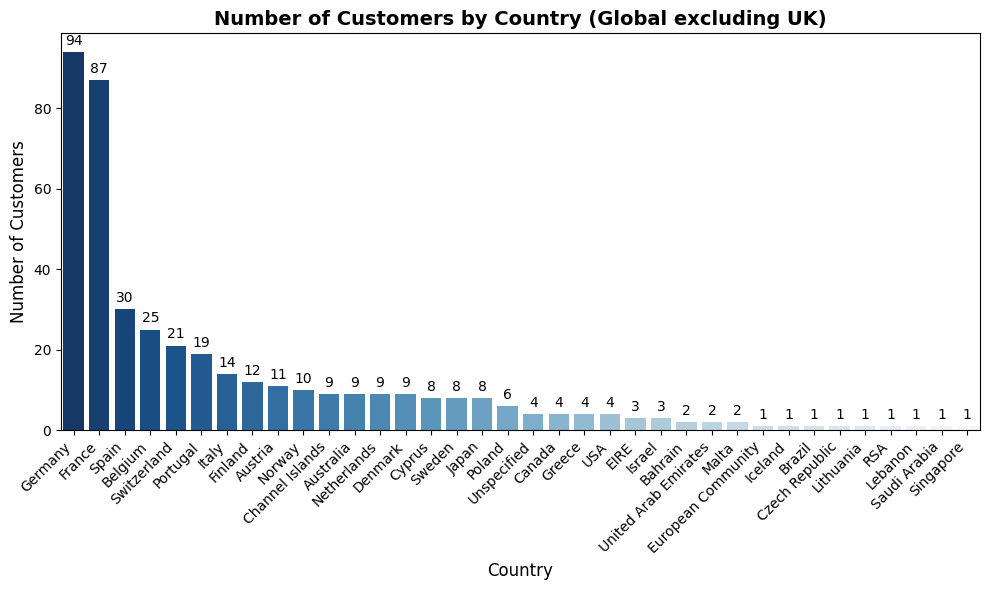

In [ ]:
country_count = (
    rfm_others_country.groupby('Country', as_index=False)['CustomerID']
    .nunique()
    .rename(columns={'CustomerID': 'CustomerCount'})
    .sort_values(by='CustomerCount', ascending=False)
)

# Sắp thứ tự Country theo số lượng khách
seg_order = country_count['Country']

# Tạo dải màu xanh đậm -> nhạt dần
palette = sns.color_palette("Blues", n_colors=len(country_count))[::-1]

# Vẽ biểu đồ
plt.figure(figsize=(10,6))
ax = sns.barplot(
    x='Country',
    y='CustomerCount',
    data=country_count,
    order=seg_order,
    hue='Country',
    legend=False,
    palette=palette
)

plt.title('Number of Customers by Country (Global excluding UK)', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Hiển thị giá trị trên cột
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

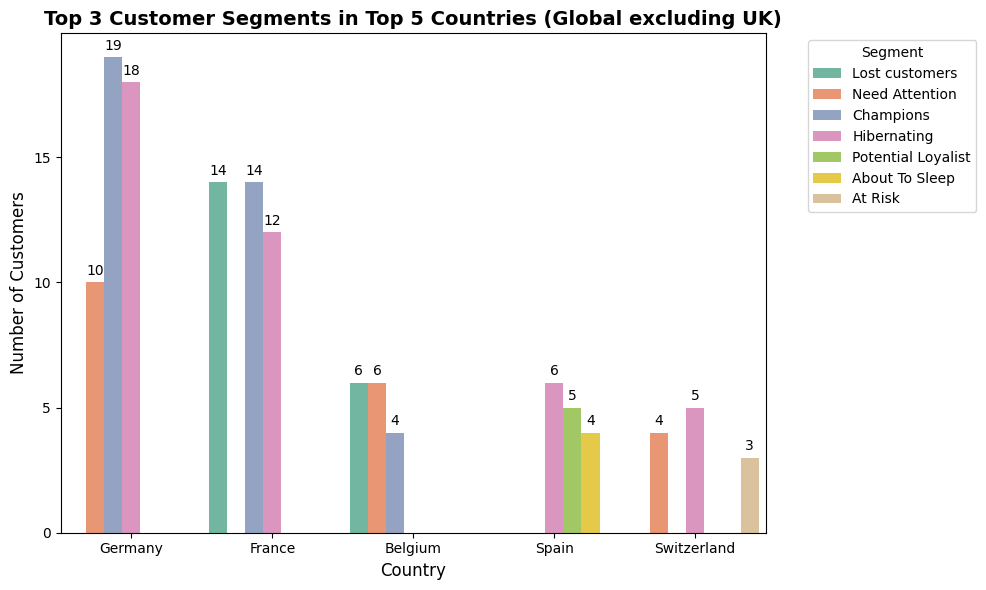

In [ ]:
rfm_share = (
    rfm_others_country
    .groupby(['Country', 'Segment'], as_index=False)
    .agg({'CustomerID': 'nunique'})
    .rename(columns={'CustomerID': 'CustomerCount'})
)

country_top5 = (
    rfm_share.groupby('Country')['CustomerCount']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

rfm_top5_seg = (
    rfm_share[rfm_share['Country'].isin(country_top5)]
    .sort_values(['Country', 'CustomerCount'], ascending=[True, False])
    .groupby('Country')
    .head(3)
)

country_order = (
    rfm_top5_seg.groupby('Country')['CustomerCount']
    .sum()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=rfm_top5_seg,
    x='Country',
    y='CustomerCount',
    hue='Segment',
    order=country_order,
    palette='Set2',
    dodge=True,
    width=0.9
)

plt.title('Top 3 Customer Segments in Top 5 Countries (Global excluding UK)', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.yaxis.get_major_locator().set_params(integer=True)

# Hiển thị nhãn số trên mỗi cột
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10, padding=3)

plt.tight_layout()
plt.show()

In [ ]:
rev_segment2 = rfm_others.groupby('Segment')['Monetary'].sum().reset_index().sort_values('Monetary', ascending=False)
rev_segment2

,Segment,Monetary
3,Champions,1034272.99
6,Loyal,139351.62
7,Need Attention,125987.06
1,At Risk,79693.84
10,Promising,64099.58
4,Hibernating,48986.79
9,Potential Loyalist,39604.00
2,Cannot Lose Them,32552.57
5,Lost customers,14713.93
0,About To Sleep,12973.21


In [ ]:
rev_segment2['Monetary_K'] = round(rev_segment2['Monetary']/ 1000,2)

rev_segment2['Revenue Share (%)'] = 100 * rev_segment2['Monetary'] / total_revenue
range_stats2 = (
    rfm_others.groupby('Segment')['Monetary']
    .agg(['min', 'max'])
    .reset_index()
)

# Gộp vào rev_segment
rev_segment2 = rev_segment2.merge(range_stats, on='Segment', how='left')
rev_segment2['Spending_Range'] = (
    rev_segment2['min'].astype(int).astype(str)
    + " - " +
    rev_segment2['max'].astype(int).astype(str)
)
rev_segment2

,Segment,Monetary,Monetary_K,Revenue Share (%),min,max,Spending_Range
0,Champions,1034272.99,1034.27,12.461022,1604.75,259657.30,1604 - 259657
1,Loyal,139351.62,139.35,1.678922,808.62,81024.84,808 - 81024
2,Need Attention,125987.06,125.99,1.517904,694.40,4932.20,694 - 4932
3,At Risk,79693.84,79.69,0.960159,319.50,44534.30,319 - 44534
4,Promising,64099.58,64.10,0.772278,52.20,168472.50,52 - 168472
5,Hibernating,48986.79,48.99,0.590198,13.30,1590.81,13 - 1590
6,Potential Loyalist,39604.00,39.60,0.477153,201.12,1592.12,201 - 1592
7,Cannot Lose Them,32552.57,32.55,0.392197,660.00,77183.60,660 - 77183
8,Lost customers,14713.93,14.71,0.177275,3.75,635.66,3 - 635
9,About To Sleep,12973.21,12.97,0.156302,6.90,1595.48,6 - 1595


/tmp/ipython-input-833633038.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


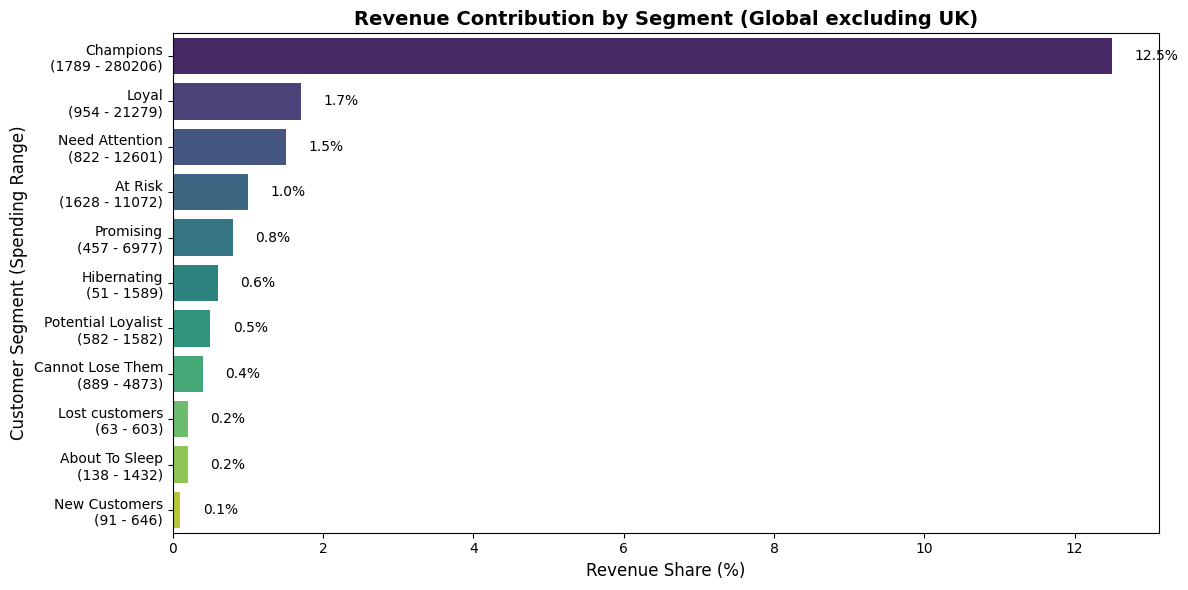

In [ ]:
# Doanh thu từng segment
revenue_by_segment = (
    rfm_others.groupby('Segment', as_index=False)
    .agg({'Monetary': 'sum'})
    .sort_values('Monetary', ascending=False)
)

# Tính tỷ trọng %
revenue_by_segment['RevenueShare'] = (revenue_by_segment['Monetary'] / total_revenue * 100).round(1)

# Format nhãn hiển thị thêm (min–max)
segment_summary = (
    rfm_others.groupby('Segment')['Monetary']
    .agg(['min', 'max'])
    .astype(int)
    .reset_index()
)

revenue_plot = revenue_by_segment.merge(segment_summary, on='Segment')

# Thêm nhãn hiển thị
revenue_plot['Segment_Label'] = (
    revenue_plot['Segment'] + '\n(' +
    revenue_plot['min'].astype(str) + ' - ' +
    revenue_plot['max'].astype(str) + ')'
)

# Vẽ biểu đồ
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=revenue_plot,
    y='Segment_Label',
    x='RevenueShare',
    palette='viridis'
)

# Tiêu đề và trục
plt.title('Revenue Contribution by Segment (Global excluding UK)', fontsize=14, fontweight='bold')
plt.xlabel('Revenue Share (%)', fontsize=12)
plt.ylabel('Customer Segment (Spending Range)', fontsize=12)

# Gắn nhãn %
for i, v in enumerate(revenue_plot['RevenueShare']):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()
